# Exploratory Data Anlasysis of the warehouse dataset

notebook objective: to understand what each file contains, how the tables are related, and what basic information each one provides.

It does not yet address a machine learning/optimization problem. The idea is to conduct a brief, organized, and methodical exploration to understand the data before defining subsequent analyses.

## imports and read data

In [36]:
from pathlib import Path

import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib.ticker as mticker


In [2]:
DATA_DIR = Path("data")

coordinates = pd.read_parquet(DATA_DIR / "coordinates.parquet")
distances = pd.read_parquet(DATA_DIR / "distances.parquet")
initial_stock = pd.read_parquet(DATA_DIR / "initial_stock.parquet")
picking_events = pd.read_parquet(DATA_DIR / "picking_events.parquet")
replenishment_events = pd.read_parquet(DATA_DIR / "replenishment_events.parquet")

## Naming conventions

The dataset uses structured identifiers to describe the warehouse layout, products, merchants, and users.

1. `bay_id`

Identifies a **bay** inside an aisle. A bay is a physical storage module that contains multiple exact storage positions.

Format:
```text
A{aisle:02d}-{bay:02d}
````
Example:
```text
bay_id = A14-21

* `A`: warehouse zone
* `14`: aisle number
* `21`: bay number within the aisle

So, `A14-21` refers to **zone A, aisle 14, bay 21**.
````
---

2. `location_name`

Identifies an **exact storage position** inside the warehouse.

Each bay contains:

* 5 shelves: `A`, `B`, `C`, `D`, `E`
* 6 bins per shelf: `01`, `02`, ..., `06`

Format:
```text
{bay_id}-{shelf}-{bin:02d}
```

Example:
```text
location_name = A14-21-B-02

* `A14-21`: zone A, aisle 14, bay 21
* `B`: shelf B
* `02`: bin 2

So, `A14-21-B-02` refers to zone A, aisle 14, bay 21, shelf B, bin 2.
```
---

3. `sku`

Identifies a product.

Format:
```text
SKU-{n:05d}
```
Example:
```text
sku = SKU-00042

This represents product 42.
```
---

4. `merchant_account_id`

Identifies the merchant or vendor associated with a product.

Format:

```text
MER-{n:03d}
```

Example:

```text
merchant_account_id = MER-007

This represents merchant 7.
```
---

5. `user_id`

Identifies a warehouse user, such as a picker or replenisher.

Format:
```text
6-digit zero-padded string
```
Example:

```text
user_id = 000017

This represents user 17.
```
---
6. `DOCK`

Special identifier for the **dock / packing station**.

Unlike a bay, `DOCK` is not a storage location. It represents the operational point used as a reference for walking distances and warehouse movement.



`bay_number` position in the bay(pasillo) zigzaged

## Datasets

### coordinates

this file contains the warehouse geometry, one row per bay and an aditional row for the `DOCK`

    bay_id       string                   Bay id, e.g. "A01-15", or "DOCK".
    zone         category(string)         Always "A"; null for DOCK.
    aisle        UInt8 (nullable)         Aisle number (1..num_aisles); null for DOCK.
    bay_number   UInt8 (nullable)         Bay index within the aisle; null for DOCK.
    side         category("odd","even")   Rack side of the aisle; null for DOCK.
                                          Odd-numbered bays sit on the lower-X side,
                                          even-numbered bays on the higher-X side.
    x            float32                  Bay center X coordinate (inches).
    y            float32                  Bay center Y coordinate (inches).


In [4]:
# dimentions

coordinates.shape
# 1001 rows = 25 ailes with 40 bays (even & odd) + DOCK

(1001, 7)

In [10]:
coordinates.head(10)

,bay_id,zone,aisle,bay_number,side,x,y
0,A01-01,A,1,1,odd,24.0,168.0
1,A01-02,A,1,2,even,168.0,168.0
2,A01-03,A,1,3,odd,24.0,264.0
3,A01-04,A,1,4,even,168.0,264.0
4,A01-05,A,1,5,odd,24.0,360.0
5,A01-06,A,1,6,even,168.0,360.0
6,A01-07,A,1,7,odd,24.0,456.0
7,A01-08,A,1,8,even,168.0,456.0
8,A01-09,A,1,9,odd,24.0,552.0
9,A01-10,A,1,10,even,168.0,552.0


In [23]:
print(coordinates["aisle"].value_counts())
# 25 ailes with 40 bays
#print(coordinates["bay_number"].value_counts()) #40 bays per aile, 25 aisles, checks out

aisle
1     40
2     40
3     40
4     40
5     40
6     40
7     40
8     40
9     40
10    40
11    40
12    40
13    40
14    40
15    40
16    40
17    40
18    40
19    40
20    40
21    40
22    40
23    40
24    40
25    40
Name: count, dtype: Int64


Note that `bay_number` is counted in a zig zaged way

Note that `bay_number` cannot be interpreted as a direct coordinate, the enum is organized in a zigzaged way, therefore bays with the same number, in different aisles can be in opposites sides (but if the parity of the aile matches, it will match)


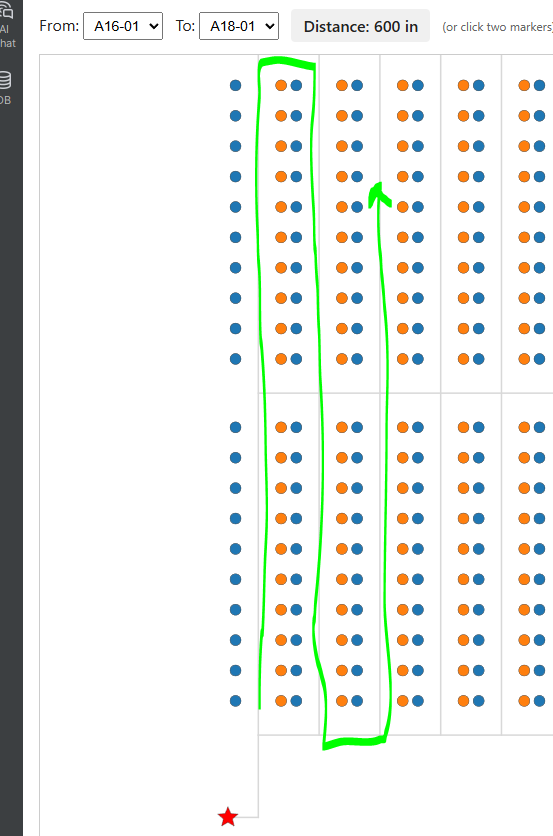
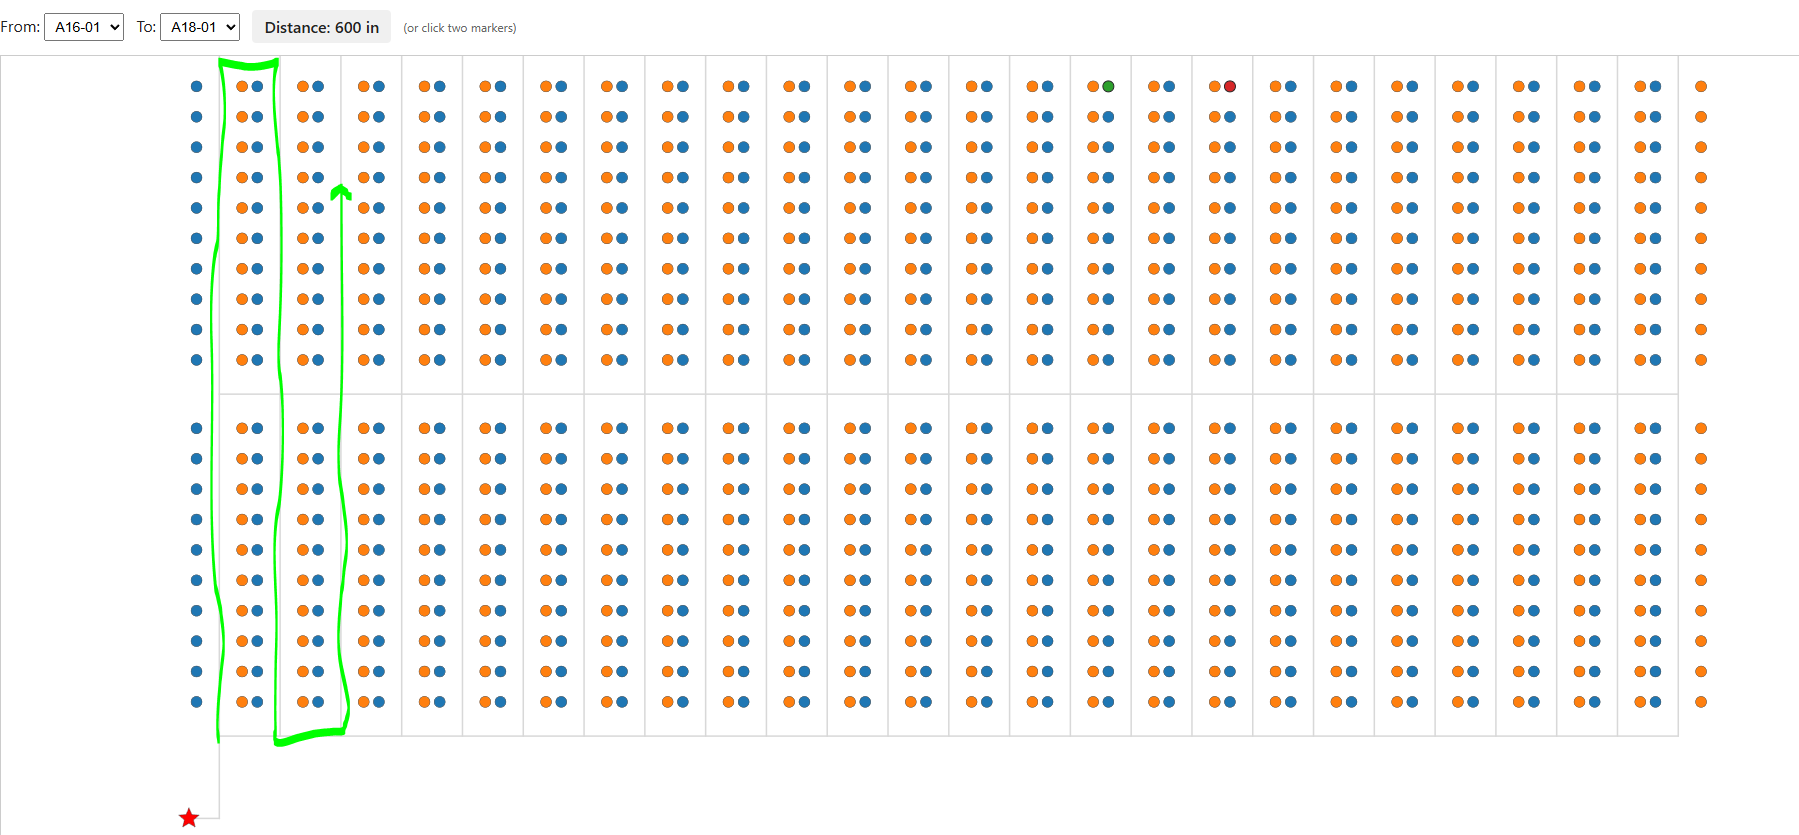

In [5]:
# Dock ubication
# it does not belog to any bay or aisle, but it has coordinates of his own
coordinates[coordinates["bay_id"] == "DOCK"]

,bay_id,zone,aisle,bay_number,side,x,y
1000,DOCK,NaN,<NA>,<NA>,NaN,0.0,-200.0


In [6]:
# example of the first bay

coordinates[coordinates["bay_id"] == "A01-01"]

,bay_id,zone,aisle,bay_number,side,x,y
0,A01-01,A,1,1,odd,24.0,168.0


In [8]:
# check distance between bays

def distance(loc1, loc2):
    p1 = coordinates[coordinates["bay_id"] == loc1]
    p2 = coordinates[coordinates["bay_id"] == loc2]

    x1, y1 = p1["x"].iloc[0], p1["y"].iloc[0]
    x2, y2 = p2["x"].iloc[0], p2["y"].iloc[0]

    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

In [9]:
distance("A01-01", "DOCK")
# this distance does not match the one in de layout.html, this is because real distance follows the lines, it´s not just euclidian


np.float32(368.78177)

### distances

This file contains walkable distances between pairs of bays, and between every bay and the `DOCK`


One row per unordered pair of bays (including the dock). No self-pairs, so the file has $C(n+1, 2)$ rows where $n$ is the bay count. Distances are
Dijkstra shortest-path walking distances over the aisle / cross-aisle
graph (rack-internal travel is not modeled).

    bay_a        string                   Lexicographically smaller id of the pair.
    bay_b        string                   Lexicographically larger id of the pair.
    distance_in  float32                  Shortest-path walking distance, inches.

In [11]:
distances.shape

# 500500 = 1000 + 999 + 9998 + ... + 3 + 2 + 1 = 1000*1001/2
# because there are no repeated entrys

(500500, 3)

In [12]:
distances.head()

,bay_a,bay_b,distance_in
0,A01-01,A01-02,0.0
1,A01-01,A01-03,96.0
2,A01-01,A01-04,96.0
3,A01-01,A01-05,192.0
4,A01-01,A01-06,192.0


The table contains each distance only once, to do this it orders each pair lexicographically

In [14]:
print(distances[distances["bay_b"] == "A01-01"].shape[0]) # A01_01 is always in bay_b
print(distances[distances["bay_b"] == "DOCK"].shape[0]) # the DOCK is always in bay_b
print(distances[distances["bay_a"] == "A25-40"]) # the last position A25-40 is only in bay_a against DOCK

0
1000
         bay_a bay_b  distance_in
500499  A25-40  DOCK       7016.0


In [65]:
distances[(distances["bay_a"] == "A01-01") & (distances["bay_b"] == "DOCK")]["distance_in"].iloc[0]
# this is the correct way to get distance between a couple of positions, a

np.float32(464.0)

In [16]:
def get_distance(distances, bay_1, bay_2):
    """
    Walkable distance between bay_1 and bay_2.

    This version works directly with the original distances DataFrame,
    without setting an index. This is simpler for exploration and small
    checks, although repeated lookups will be faster if distances is later
    indexed by ["bay_a", "bay_b"].

    Parameters
    ----------
    distances : pd.DataFrame
        DataFrame with columns ["bay_a", "bay_b", "distance_in"].
        Each unordered pair is stored once, with bay_a and bay_b ordered
        lexicographically.
    bay_1 : str
        First bay id, e.g. "A01-01" or "DOCK".
    bay_2 : str
        Second bay id, e.g. "A02-40" or "DOCK".

    Returns
    -------
    float
        Walkable distance in inches.
    """
    if bay_1 == bay_2:
        return 0.0

    bay_a, bay_b = sorted([bay_1, bay_2])

    row = distances.loc[
        (distances["bay_a"] == bay_a) &
        (distances["bay_b"] == bay_b),
        "distance_in"
    ]

    if row.empty:
        raise ValueError(f"No distance found between {bay_1} and {bay_2}")

    return row.iloc[0]

In [18]:
# example
print(get_distance(distances, "DOCK", "A01-01"))
print(get_distance(distances, "A01-01", "DOCK"))


464.0
464.0


Walkable distances distribution

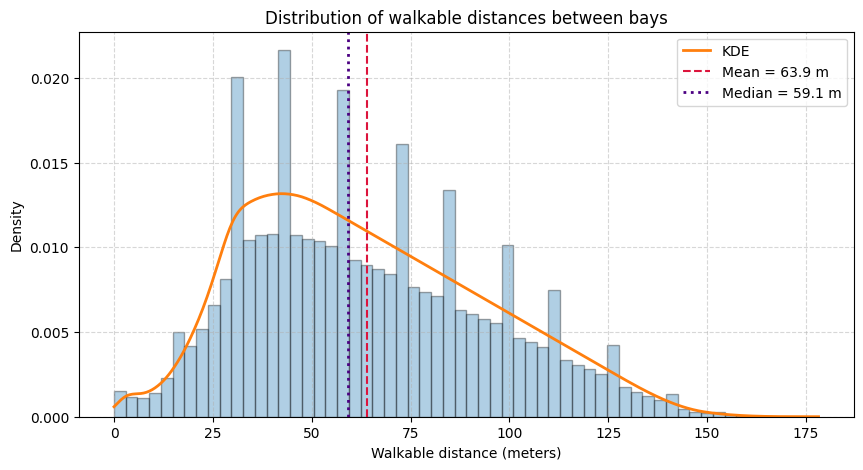

In [19]:
from scipy.stats import gaussian_kde

x = distances["distance_in"].to_numpy()

# convert inches to meters for interpretability
x_m = x * 0.0254

# KDE
kde = gaussian_kde(x_m)
grid = np.linspace(x_m.min(), x_m.max(), 500)
density = kde(grid)

plt.figure(figsize=(10, 5))
plt.hist(x_m,bins=60,density=True,alpha=0.35,edgecolor="black")

plt.plot(grid,density,linewidth=2,label="KDE")


plt.axvline(x_m.mean(),
    linestyle="--",linewidth=1.5,color="crimson",label=f"Mean = {x_m.mean():.1f} m")
plt.axvline(np.median(x_m),
    linestyle=":", linewidth=2, color="indigo", label=f"Median = {np.median(x_m):.1f} m")

plt.title("Distribution of walkable distances between bays")
plt.xlabel("Walkable distance (meters)")
plt.ylabel("Density")
plt.legend()
plt.grid(linestyle = '--',alpha=0.5)
plt.show()

### initial_stock

This files represents the initial state of the whole inventory, observation unit is not the bay but the exact location (bay, shelf, bin)

One row per (bay, shelf, bin) location in the pickable zone. Empty
locations are included with null sku / merchant and 0 units. One SKU
per location; SKUs are 1:1 with non-empty locations.

    location_id           UInt32          Stable surrogate key (1..N). Referenced
                                          by picking_events and replenishment_events.
    location_name         string          Full location id, e.g. "A14-21-B-02".
    bay_id                string          Bay containing this location, e.g. "A14-21".
    sku                   string (null)   SKU stored here; null if location is empty.
    merchant_account_id   string (null)   Merchant that owns the SKU; null if empty.
    units                 UInt16          Initial stock units; 0 for empty locations.

A bay contains multiple inner locations, in this warehouse, each bay has 5 shelves and every shelf has 6 bins, ending up with 30 exact locations per bay

A{xx}-{yy}-{s}-{BB}

indicates:
- Aile xx(pasillo)
- bay yy in Aile(zigzaged)


this two params describe a `bay`

- inside a bay there are 5 shelves (A,...E), param s
- inside each shelf there are 6 bins, param BB


In [20]:
print("Shape:", initial_stock.shape)


Shape: (30000, 6)


In [21]:
initial_stock.head()

,location_id,location_name,bay_id,sku,merchant_account_id,units
0,1,A01-01-A-01,A01-01,SKU-00001,MER-001,12
1,2,A01-01-A-02,A01-01,SKU-00002,MER-010,19
2,3,A01-01-A-03,A01-01,SKU-00003,MER-001,10
3,4,A01-01-A-04,A01-01,SKU-00004,MER-009,16
4,5,A01-01-A-05,A01-01,SKU-00005,MER-007,43


In [22]:
initial_stock["location_id"].max()
#  (25 aisles * 40 bays/aile = 1000 bays) * 5 shelf/bin * 6 bins/shelf = 1000*5*6=30000 exact locations

np.uint32(30000)

In [23]:
print("Unique bays:", initial_stock["bay_id"].nunique())
print("Unique locations:", initial_stock["location_id"].nunique())

Unique bays: 1000
Unique locations: 30000


In [25]:
locations_per_bay = (
    initial_stock
    .groupby("bay_id")["location_id"]
    .nunique()
    .value_counts()
    .sort_index()
)
locations_per_bay #check, every bay has 30 locations

location_id
30    1000
Name: count, dtype: int64

In [26]:
# every location from A01-01
# 5 shelves A,B,C,D,E
# 6 bins 1,2,3,4,5,6
initial_stock[initial_stock["bay_id"] == "A01-01"].sort_values("location_name").head(30)

,location_id,location_name,bay_id,sku,merchant_account_id,units
0,1,A01-01-A-01,A01-01,SKU-00001,MER-001,12
1,2,A01-01-A-02,A01-01,SKU-00002,MER-010,19
2,3,A01-01-A-03,A01-01,SKU-00003,MER-001,10
3,4,A01-01-A-04,A01-01,SKU-00004,MER-009,16
4,5,A01-01-A-05,A01-01,SKU-00005,MER-007,43
5,6,A01-01-A-06,A01-01,SKU-00006,MER-001,19
6,7,A01-01-B-01,A01-01,SKU-00007,MER-002,52
7,8,A01-01-B-02,A01-01,SKU-00008,MER-006,25
8,9,A01-01-B-03,A01-01,SKU-00009,MER-004,27
9,10,A01-01-B-04,A01-01,SKU-00010,MER-001,14


In [27]:
print("Unique SKUs:", initial_stock["sku"].nunique(dropna=True))
# 27000 unique SKUs and 3000 empty slots available

Unique SKUs: 27000


In [28]:
# Missing values and dtypes
summary = pd.DataFrame({
    "dtype": initial_stock.dtypes,
    "missing_values": initial_stock.isna().sum(),
    "missing_pct": initial_stock.isna().mean() * 100,
    "unique_values": initial_stock.nunique(dropna=True)
})
# we expect some missing values in the SKU(and his vendor)
summary

,dtype,missing_values,missing_pct,unique_values
location_id,uint32,0,0.0,30000
location_name,string,0,0.0,30000
bay_id,string,0,0.0,1000
sku,string,3000,10.0,27000
merchant_account_id,string,3000,10.0,10
units,uint16,0,0.0,121


In [29]:
# Occupancy status
initial_stock_eda = initial_stock.copy()

initial_stock_eda["is_empty"] = initial_stock_eda["sku"].isna()

occupancy = (
    initial_stock_eda["is_empty"]
    .value_counts()
    .rename(index={False: "occupied", True: "empty"})
    .to_frame("count")
)

occupancy["pct"] = occupancy["count"] / occupancy["count"].sum() * 100

occupancy

,count,pct
is_empty,,
occupied,27000,90.0
empty,3000,10.0


In [30]:
# get empty locations
initial_stock_eda[initial_stock_eda["units"] == 0].head()

,location_id,location_name,bay_id,sku,merchant_account_id,units,is_empty
13,14,A01-01-C-02,A01-01,<NA>,<NA>,0,True
18,19,A01-01-D-01,A01-01,<NA>,<NA>,0,True
37,38,A01-02-B-02,A01-02,<NA>,<NA>,0,True
51,52,A01-02-D-04,A01-02,<NA>,<NA>,0,True
55,56,A01-02-E-02,A01-02,<NA>,<NA>,0,True


units per exact location distribution

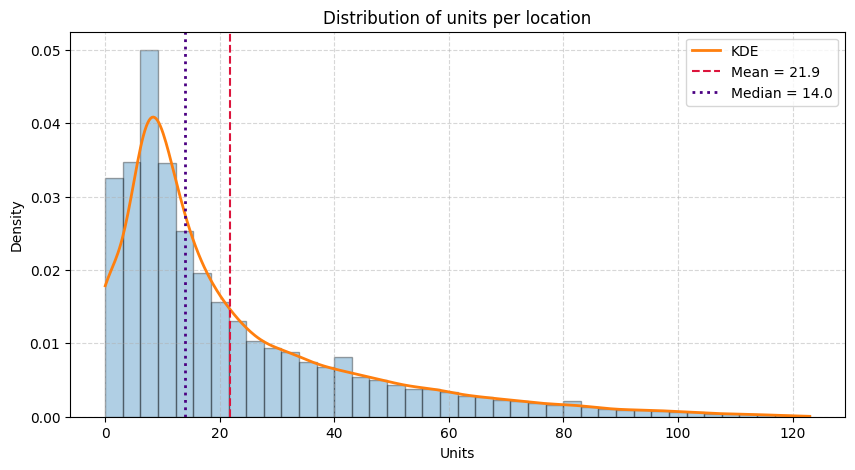

In [32]:
occupied_stock = initial_stock_eda[~initial_stock_eda["is_empty"]].copy()

# Unit values
x = initial_stock_eda["units"].to_numpy()

# KDE
kde = gaussian_kde(x)
grid = np.linspace(x.min(), x.max(), 500)
density = kde(grid)

plt.figure(figsize=(10, 5))
plt.hist(x,bins=40,density=True,alpha=0.35,edgecolor="black")
plt.plot(grid,density,linewidth=2,label="KDE")

plt.axvline(x.mean(),
    linestyle="--",linewidth=1.5,color="crimson",label=f"Mean = {x.mean():.1f}")
plt.axvline(np.median(x),
    linestyle=":",linewidth=2,color="indigo",label=f"Median = {np.median(x):.1f}")

plt.title("Distribution of units per location")
plt.xlabel("Units")
plt.ylabel("Density")
plt.legend()
plt.grid(linestyle="--", alpha=0.5)
plt.show()

In [37]:
# only 9 vendors
initial_stock_eda["merchant_account_id"].value_counts()

merchant_account_id
MER-008    2805
MER-007    2736
MER-005    2734
MER-003    2729
MER-010    2706
MER-004    2678
MER-006    2677
MER-002    2656
MER-001    2653
MER-009    2626
Name: count, dtype: int64[pyarrow]

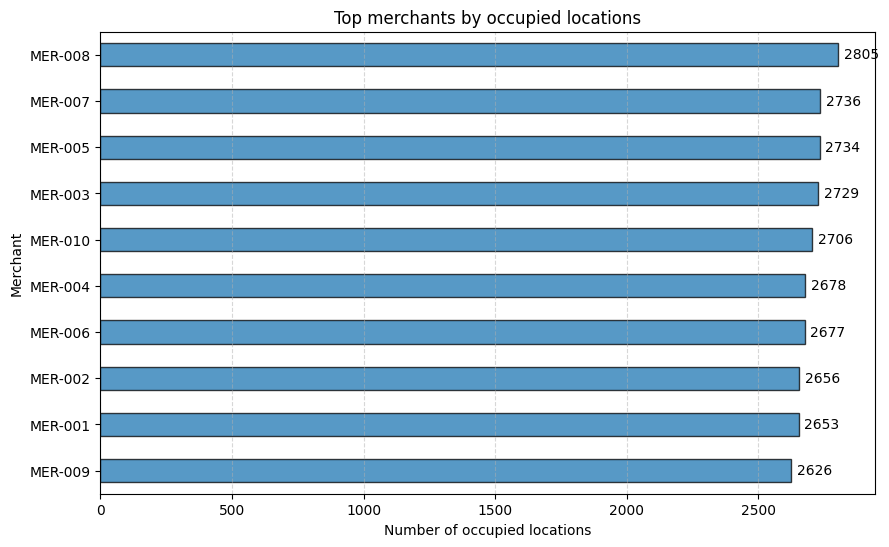

In [38]:
occupied_stock = initial_stock_eda[~initial_stock_eda["is_empty"]].copy()

top_merchants_locations = occupied_stock.groupby("merchant_account_id").size().sort_values(ascending=False).head(15)
top_merchants_df = top_merchants_locations.to_frame("occupied_locations")
top_merchants_df["share"] = top_merchants_df["occupied_locations"] / len(occupied_stock)

ax = top_merchants_locations.sort_values().plot(kind="barh", figsize=(10, 6), edgecolor="black", alpha=0.75)

ax.bar_label(ax.containers[0], padding=4)
plt.title("Top merchants by occupied locations")
plt.xlabel("Number of occupied locations")
plt.ylabel("Merchant")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

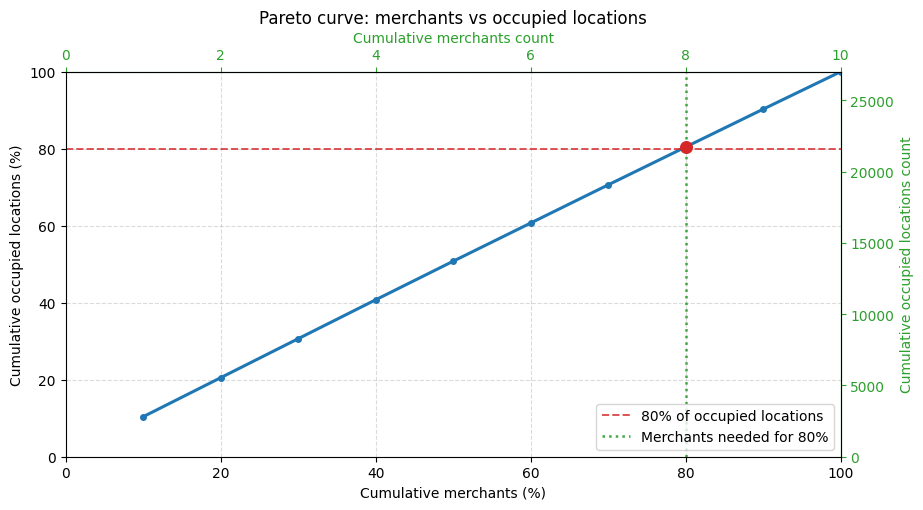

In [138]:
# pareto of merchants
# no usefull insights

occupied_stock = initial_stock_eda[~initial_stock_eda["is_empty"]].copy()

merchant_locations = occupied_stock.groupby("merchant_account_id").size().sort_values(ascending=False).to_frame("occupied_locations")
merchant_locations["cum_locations"] = merchant_locations["occupied_locations"].cumsum()
merchant_locations["cum_merchants"] = np.arange(1, len(merchant_locations) + 1)

total_merchants = len(merchant_locations)
total_locations = merchant_locations["occupied_locations"].sum()

merchant_locations["cum_merchants_pct"] = merchant_locations["cum_merchants"] / total_merchants * 100
merchant_locations["cum_locations_pct"] = merchant_locations["cum_locations"] / total_locations * 100

pareto_80 = merchant_locations[merchant_locations["cum_locations_pct"] >= 80].iloc[0]

count_color = "tab:green"
line_color = "tab:blue"

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(merchant_locations["cum_merchants_pct"], merchant_locations["cum_locations_pct"], marker="o", markersize=4, linewidth=2.2, color=line_color)
ax.scatter(pareto_80["cum_merchants_pct"], pareto_80["cum_locations_pct"], s=70, color="tab:red", zorder=3)

ax.axhline(80, linestyle="--", linewidth=1.4, color="tab:red", alpha=0.8, label="80% of occupied locations")
ax.axvline(pareto_80["cum_merchants_pct"], linestyle=":", linewidth=1.8, color=count_color, alpha=0.9, label="Merchants needed for 80%")

ax.set_title("Pareto curve: merchants vs occupied locations")
ax.set_xlabel("Cumulative merchants (%)")
ax.set_ylabel("Cumulative occupied locations (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(linestyle="--", alpha=0.45)
ax.legend(loc="lower right")

secax_x = ax.secondary_xaxis("top", functions=(lambda p: p / 100 * total_merchants, lambda n: n / total_merchants * 100))
secax_y = ax.secondary_yaxis("right", functions=(lambda p: p / 100 * total_locations, lambda n: n / total_locations * 100))

secax_x.set_xlabel("Cumulative merchants count")
secax_y.set_ylabel("Cumulative occupied locations count")

secax_x.xaxis.label.set_color(count_color)
secax_y.yaxis.label.set_color(count_color)
secax_x.tick_params(axis="x", colors=count_color)
secax_y.tick_params(axis="y", colors=count_color)
secax_x.spines["top"].set_color(count_color)
secax_y.spines["right"].set_color(count_color)

secax_x.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.0f}"))
secax_y.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, pos: f"{y:.0f}"))

plt.show()

In [40]:
# occupancy by bay

locations_per_bay = (
    initial_stock
    .groupby("bay_id")
    .agg(
        total_locations=("location_id", "count"),
        occupied_locations=("sku", lambda s: s.notna().sum()),
        empty_locations=("sku", lambda s: s.isna().sum()),
        total_units=("units", "sum")
    )
    .reset_index()
)

locations_per_bay["occupancy_rate"] = (
    locations_per_bay["occupied_locations"] / locations_per_bay["total_locations"]
)

In [41]:
locations_per_bay.head()

,bay_id,total_locations,occupied_locations,empty_locations,total_units,occupancy_rate
0,A01-01,30,28,2,633,0.933333
1,A01-02,30,27,3,887,0.9
2,A01-03,30,27,3,799,0.9
3,A01-04,30,27,3,774,0.9
4,A01-05,30,30,0,673,1.0


In [42]:
locations_per_bay.describe()


,total_locations,occupied_locations,empty_locations,total_units,occupancy_rate
count,1000.0,1000.0,1000.0,1000.000000,1000.0
mean,30.0,27.0,3.0,655.875000,0.9
std,0.0,1.595163,1.595163,116.809922,0.053172
min,30.0,21.0,0.0,340.000000,0.7
25%,30.0,26.0,2.0,576.000000,0.866667
50%,30.0,27.0,3.0,654.500000,0.9
75%,30.0,28.0,4.0,729.000000,0.933333
max,30.0,30.0,9.0,1095.000000,1.0


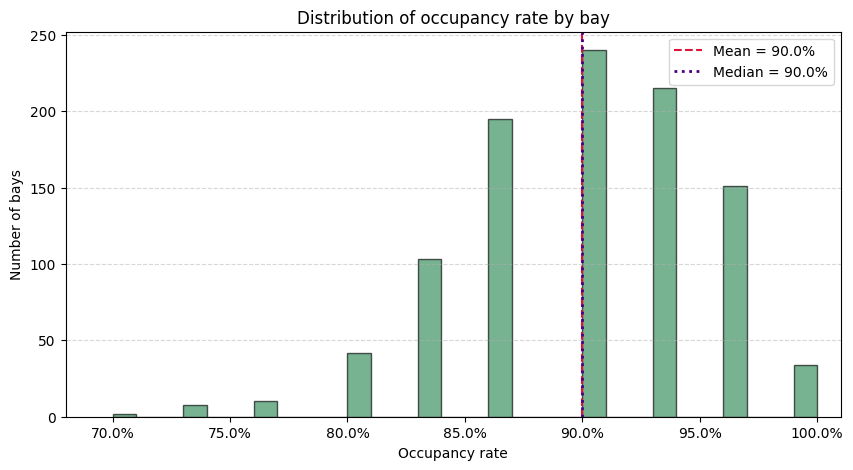

In [43]:
# since there are only 30 locations in a bay, there cannot be any number of occupancy rate
x = locations_per_bay["occupancy_rate"].dropna()

plt.figure(figsize=(10, 5))
plt.hist(x, bins=30, edgecolor="black", color="seagreen", alpha=0.65)
plt.axvline(x.mean(), linestyle="--", linewidth=1.5, color="crimson", label=f"Mean = {x.mean():.1%}")
plt.axvline(x.median(), linestyle=":", linewidth=2, color="indigo", label=f"Median = {x.median():.1%}")
plt.title("Distribution of occupancy rate by bay")
plt.xlabel("Occupancy rate")
plt.ylabel("Number of bays")
plt.xlim(max(0, x.min() - 0.02), 1.01)
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [44]:
# Parse bay_id: "A14-21" -> aisle = 14, bay_number = 21
initial_stock_eda[["zone", "aisle_bay"]] = initial_stock_eda["bay_id"].str.extract(r"([A-Z])(\d{2}-\d{2})")
initial_stock_eda[["aisle", "bay_number"]] = initial_stock_eda["aisle_bay"].str.split("-", expand=True).astype(int)

initial_stock_eda = initial_stock_eda.drop(columns=["aisle_bay"])

display(initial_stock_eda.head())

,location_id,location_name,bay_id,sku,merchant_account_id,units,is_empty,zone,aisle,bay_number
0,1,A01-01-A-01,A01-01,SKU-00001,MER-001,12,False,A,1,1
1,2,A01-01-A-02,A01-01,SKU-00002,MER-010,19,False,A,1,1
2,3,A01-01-A-03,A01-01,SKU-00003,MER-001,10,False,A,1,1
3,4,A01-01-A-04,A01-01,SKU-00004,MER-009,16,False,A,1,1
4,5,A01-01-A-05,A01-01,SKU-00005,MER-007,43,False,A,1,1


In [45]:
occupancy_by_aisle = (
    initial_stock_eda
    .groupby("aisle")
    .agg(
        total_locations=("location_id", "count"),
        occupied_locations=("sku", lambda s: s.notna().sum()),
        empty_locations=("sku", lambda s: s.isna().sum()),
        total_units=("units", "sum")
    )
    .reset_index()
)

occupancy_by_aisle["occupancy_rate"] = (
    occupancy_by_aisle["occupied_locations"] / occupancy_by_aisle["total_locations"]
)

occupancy_by_aisle.head()

,aisle,total_locations,occupied_locations,empty_locations,total_units,occupancy_rate
0,1,1200,1108,92,27409,0.923333
1,2,1200,1069,131,25609,0.890833
2,3,1200,1068,132,27331,0.89
3,4,1200,1077,123,25505,0.8975
4,5,1200,1085,115,26339,0.904167


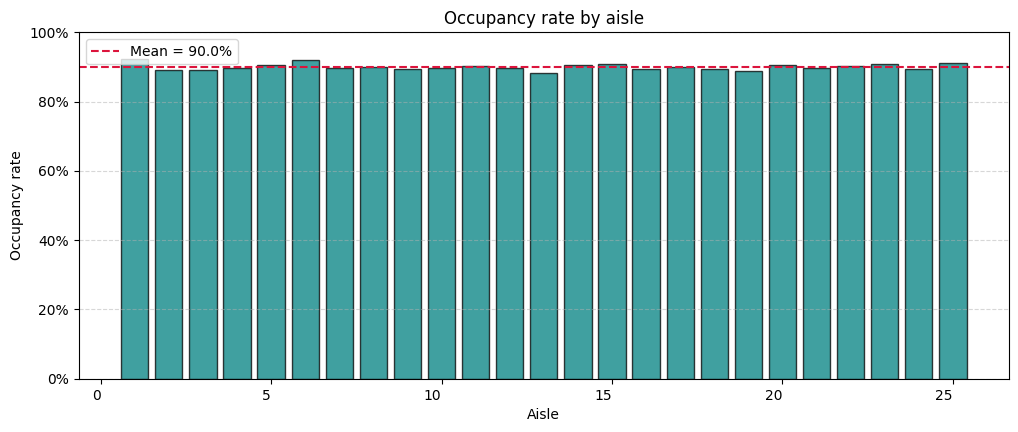

In [46]:

plot_df = occupancy_by_aisle.sort_values("aisle").copy()
mean_occupancy = plot_df["occupancy_rate"].mean()

plt.figure(figsize=(12, 4.5))
plt.bar(plot_df["aisle"], plot_df["occupancy_rate"], edgecolor="black", color="teal",alpha=0.75)
plt.axhline(mean_occupancy, linestyle="--", linewidth=1.5, color="crimson", label=f"Mean = {mean_occupancy:.1%}")
plt.title("Occupancy rate by aisle")
plt.xlabel("Aisle")
plt.ylabel("Occupancy rate")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.xticks(ha="right")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Occupancy is uniformly distributed across vendors, aisles,bays, shelves and bins

### picking_events

This file has the picking history, each row is a pick line, ie an SKU retired from an exact ubication, in a specific time, to fulfill an order

Again, the objective is to understand volumes, temporal indicators and basic activity distribution

One row per pick line. Picks are organized in batches of orders; within
a batch lines are sorted in snake/S-shape order by (aisle, bay_number,
shelf, bin). Each batch is executed by exactly one picker.

    batch_id              string          Batch identifier (shared across the lines
                                          of the batch).
    timestamp             datetime64[ns]  When the pick happened.
    user_id               string          Picker id (6-digit zero-padded).
    location_id           UInt32          Location picked from (joins to
                                          initial_stock.location_id).
    location_name         string          Full location id of the pick.
    bay_name              string          Bay id of the pick (e.g. "A14-21").
    sku                   string          SKU picked.
    merchant_account_id   string          Merchant of the SKU. All lines in an
                                          order share the same merchant.
    quantity              UInt16          Units picked on this line.

In [49]:
print("Shape:", picking_events.shape)

Shape: (174597, 9)


In [48]:
picking_events.head()

,batch_id,timestamp,user_id,location_id,location_name,bay_name,sku,merchant_account_id,quantity
0,BATCH-000001,2025-01-01 08:00:27.533333,064058,181,A01-07-A-01,A01-07,SKU-00169,MER-009,2
1,BATCH-000001,2025-01-01 08:00:42.533333,064058,181,A01-07-A-01,A01-07,SKU-00169,MER-009,2
2,BATCH-000001,2025-01-01 08:00:57.533333,064058,181,A01-07-A-01,A01-07,SKU-00169,MER-009,1
3,BATCH-000001,2025-01-01 08:01:28.933333,064058,1815,A02-21-C-03,A02-21,SKU-01653,MER-003,2
4,BATCH-000001,2025-01-01 08:01:43.933333,064058,1815,A02-21-C-03,A02-21,SKU-01653,MER-003,3


In [55]:
len(picking_events)

174597

In [62]:
print("Date range:")
print(picking_events["timestamp"].min(), "  -  ", picking_events["timestamp"].max(),end="\n\n")
print("="*12 + "Basic counts" +"="*12)


print(f"{'Pick lines (nrows)':<24}: {len(picking_events):>10,}")
print(f"{'Batches (picks)':<24}: {picking_events['batch_id'].nunique():>10,}")
print(f"{'Pickers':<24}: {picking_events['user_id'].nunique():>10,}")
print(f"{'Locations picked':<24}: {picking_events['location_id'].nunique():>10,}")
print(f"{'Bays picked':<24}: {picking_events['bay_name'].nunique():>10,}")
print(f"{'SKUs picked':<24}: {picking_events['sku'].nunique():>10,}")
print(f"{'Merchants':<24}: {picking_events['merchant_account_id'].nunique():>10,}")
print(f"{'Total units picked':<24}: {picking_events['quantity'].sum():>10,}")

Date range:
2025-01-01 08:00:27.533333   -   2025-01-31 18:13:32.133333

============Basic counts============
Pick lines (nrows)      :    174,597
Batches (picks)         :      2,000
Pickers                 :         20
Locations picked        :     19,853
Bays picked             :      1,000
SKUs picked             :     17,201
Merchants               :         10
Total units picked      :    349,397


In [63]:
# Daly picks


picking_eda = picking_events.copy()
picking_eda["date"] = picking_eda["timestamp"].dt.date

picks_by_day = (
    picking_eda
    .groupby("date")
    .agg(
        pick_lines=("batch_id", "size"),
        total_units=("quantity", "sum"),
        batches=("batch_id", "nunique")
    )
    .reset_index()
)

display(picks_by_day.head())

,date,pick_lines,total_units,batches
0,2025-01-01,3818,7657,44
1,2025-01-02,5673,11286,67
2,2025-01-03,5799,11512,68
3,2025-01-04,5727,11426,68
4,2025-01-05,5721,11417,67


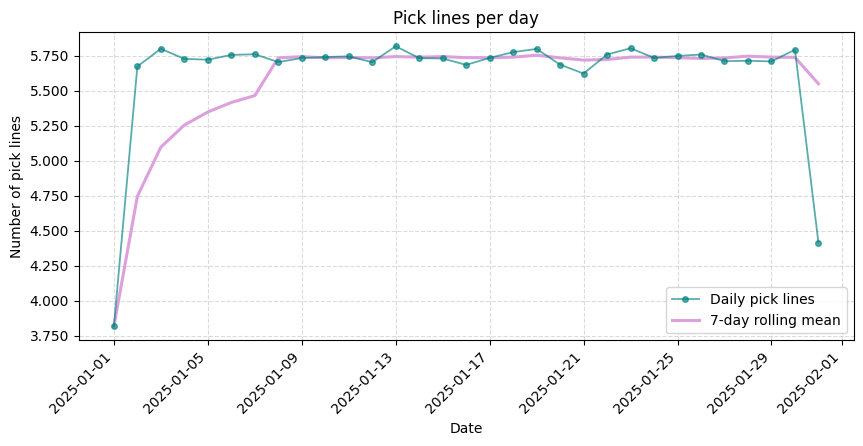

In [69]:
plot_df = picks_by_day.sort_values("date").copy()
plot_df["rolling_7d"] = plot_df["pick_lines"].rolling(7, min_periods=1).mean()

plt.figure(figsize=(10, 4))
plt.plot(plot_df["date"], plot_df["pick_lines"], marker="o", markersize=4, linewidth=1.3, alpha=0.65, label="Daily pick lines",zorder=5,color="teal")
plt.plot(plot_df["date"], plot_df["rolling_7d"], linewidth=2.2, label="7-day rolling mean",zorder=3,color="plum")
plt.title("Pick lines per day")
plt.xlabel("Date")
plt.ylabel("Number of pick lines")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(linestyle="--", alpha=0.45)
plt.show()

In [71]:

batch_size = (
    picking_events
    .groupby("batch_id")
    .size()
    .rename("pick_lines_per_batch")
)


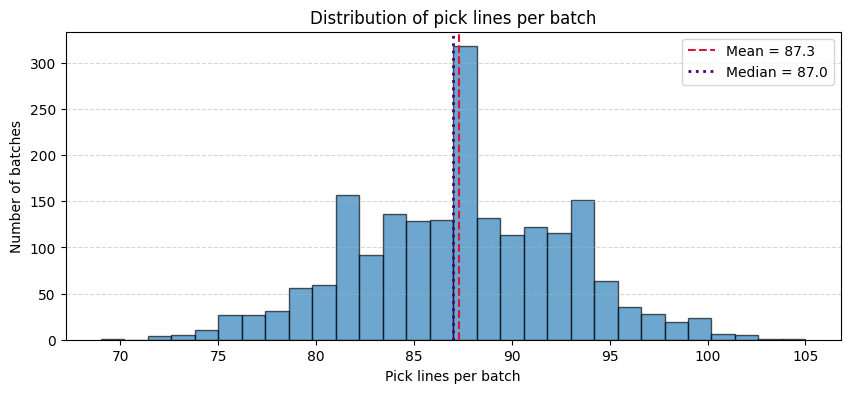

In [74]:
x = batch_size.dropna()

plt.figure(figsize=(10, 4))
plt.hist(x, bins=30, edgecolor="black", alpha=0.65)
plt.axvline(x.mean(), linestyle="--", linewidth=1.5, color="crimson", label=f"Mean = {x.mean():.1f}")
plt.axvline(x.median(), linestyle=":", linewidth=2, color="indigo", label=f"Median = {x.median():.1f}")
plt.title("Distribution of pick lines per batch")
plt.xlabel("Pick lines per batch")
plt.ylabel("Number of batches")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [174]:
picks_by_picker = (
    picking_events
    .groupby("user_id")
    .agg(
        pick_lines=("batch_id", "size"),
        total_units=("quantity", "sum"),
        batches=("batch_id", "nunique")
    )
    .sort_values("pick_lines", ascending=False)
)

picks_by_picker.head(10)

,pick_lines,total_units,batches
user_id,,,
761272,8787,17624,100
413389,8785,17519,100
291555,8784,17591,100
914968,8778,17504,100
742225,8762,17641,100
148529,8762,17405,100
723960,8752,17522,100
247580,8743,17371,100
101442,8741,17536,100


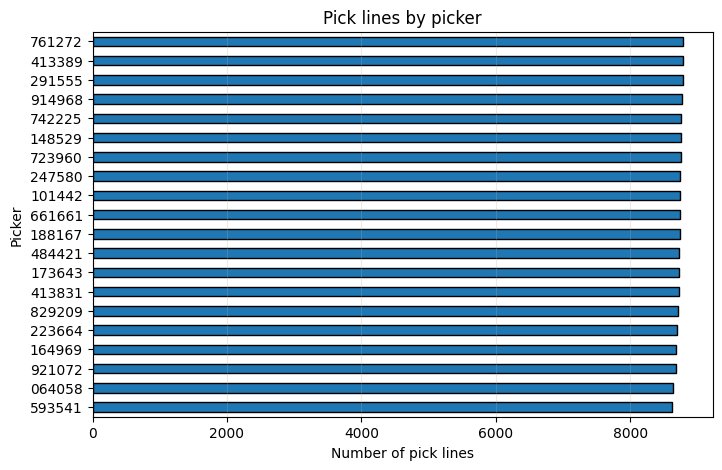

In [175]:
picks_by_picker["pick_lines"].sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Pick lines by picker")
plt.xlabel("Number of pick lines")
plt.ylabel("Picker")
plt.grid(axis="x", alpha=0.25)
plt.show()

batches are distributed uniformly across pickers

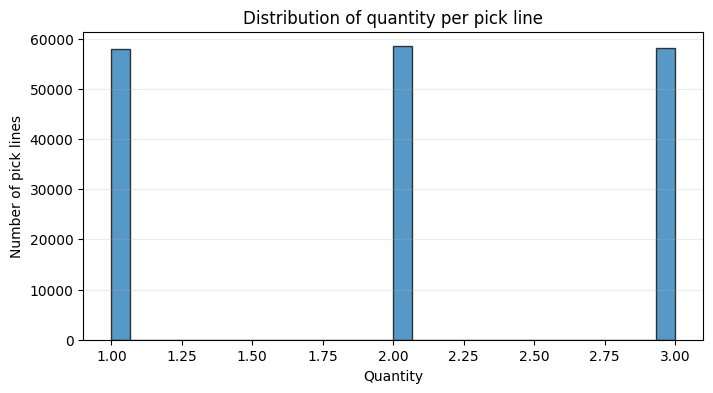

In [79]:
picking_events["quantity"].describe()

plt.figure(figsize=(8, 4))

plt.hist(
    picking_events["quantity"],
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.title("Distribution of quantity per pick line")
plt.xlabel("Quantity")
plt.ylabel("Number of pick lines")
plt.grid(axis="y", alpha=0.25)
plt.show()

#### most picked skus

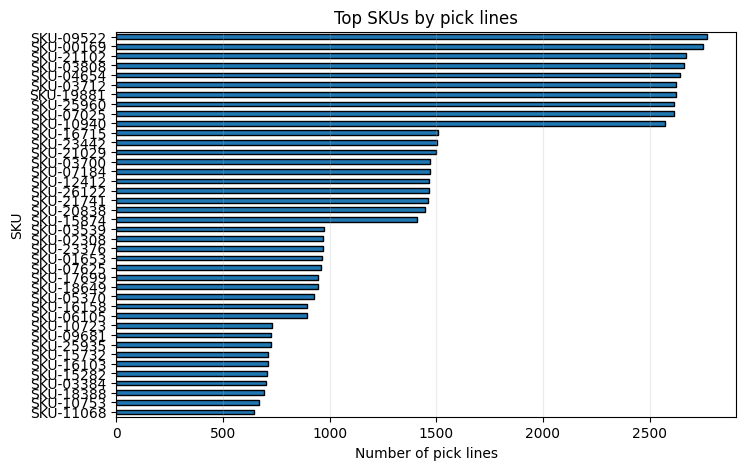

In [82]:
top_skus = (
    picking_events
    .groupby("sku")
    .agg(
        pick_lines=("batch_id", "size"),
        total_units=("quantity", "sum")
    )
    .sort_values("pick_lines", ascending=False)
    .head(40)
)

top_skus["pick_lines"].sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Top SKUs by pick lines")
plt.xlabel("Number of pick lines")
plt.ylabel("SKU")
plt.grid(axis="x", alpha=0.25)
plt.show()

skus orders, follow this step distribution

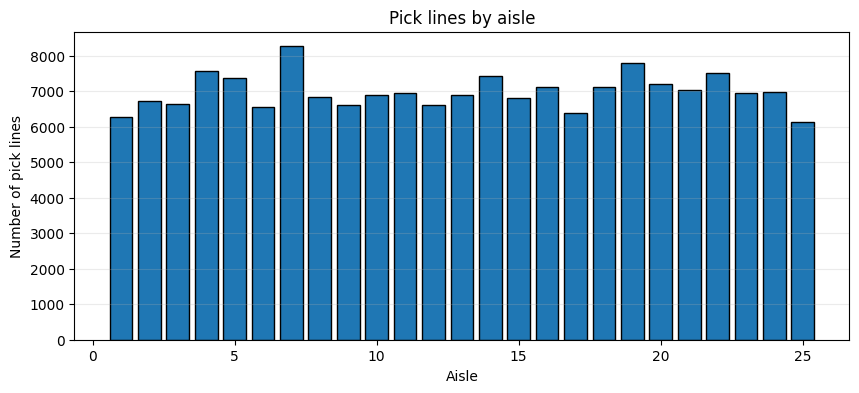

In [83]:
picking_eda["aisle"] = picking_eda["bay_name"].str.extract(r"A(\d{2})-")[0].astype(int)

picks_by_aisle = (
    picking_eda
    .groupby("aisle")
    .agg(
        pick_lines=("batch_id", "size"),
        total_units=("quantity", "sum"),
        unique_skus=("sku", "nunique")
    )
    .reset_index()
)

plt.figure(figsize=(10, 4))

plt.bar(
    picks_by_aisle["aisle"],
    picks_by_aisle["pick_lines"],
    edgecolor="black"
)

plt.title("Pick lines by aisle")
plt.xlabel("Aisle")
plt.ylabel("Number of pick lines")
plt.grid(axis="y", alpha=0.25)
plt.show()

the aisle distribution by pick lines is somewhat uniform